# 05 — Texas Energy–Economy Overview

This notebook provides the first descriptive overview of the integrated monthly Texas energy-and-economy dataset.

It examines:

- real residential electricity prices and Henry Hub natural-gas prices;
- Texas employment growth and WTI crude-oil price changes;
- renewable generation shares and real residential electricity prices;
- correlations among selected indicators;
- descriptive lead–lag patterns.

The results are descriptive and should not be interpreted as causal estimates.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


CURRENT_DIRECTORY = Path.cwd()

if (CURRENT_DIRECTORY / "data").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY
elif (CURRENT_DIRECTORY.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root. "
        f"Current directory: {CURRENT_DIRECTORY}"
    )

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "tx_energy_economy_monthly.csv"
)

FIGURE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "figures"
)

TABLE_DIRECTORY = (
    PROJECT_ROOT
    / "reports"
    / "tables"
)

FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
TABLE_DIRECTORY.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The integrated monthly dataset was not found. "
        "Run `python src/build_energy_economy_dataset.py` first."
    )

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["period"],
)

df = (
    df.sort_values("period")
    .reset_index(drop=True)
)

if df["period"].duplicated().any():
    raise ValueError(
        "Duplicate monthly observations were found."
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
print(
    f"Date range: "
    f"{df['period'].min():%Y-%m} to "
    f"{df['period'].max():%Y-%m}"
)

df.head()

Project root: C:\Users\13393\PycharmProjects\texas-energy-economy-monitor
Rows: 137
Columns: 113
Date range: 2015-01 to 2026-05


,period,commercial_customers,commercial_price,commercial_revenue,commercial_sales,industrial_customers,industrial_price,industrial_revenue,industrial_sales,residential_customers,...,tx_total_nonfarm_employment,tx_unemployment_rate,us_cpi,tx_nonfarm_employment_yoy_pct,tx_unemployment_rate_yoy_pp,wti_crude_oil_price_yoy_pct,henry_hub_natural_gas_price_yoy_pct,residential_price_real_2025_01,commercial_price_real_2025_01,industrial_price_real_2025_01
0,2015-01-01,1424841.0,8.40,910.06698,10834.88707,97914.0,5.93,502.67896,8481.28780,10236358.0,...,11804.0,4.5,234.747,NaN,NaN,NaN,NaN,15.611965,11.413447,8.057350
1,2015-02-01,1414177.0,8.50,842.24433,9903.83625,101493.0,5.84,471.33029,8076.96359,10222635.0,...,11810.8,4.5,235.342,NaN,NaN,NaN,NaN,15.748684,11.520122,7.915001
2,2015-03-01,1421352.0,8.49,895.83199,10548.75206,102666.0,5.79,502.20327,8667.54624,10292791.0,...,11804.5,4.5,235.976,NaN,NaN,NaN,NaN,15.625272,11.475654,7.826153
3,2015-04-01,1417183.0,7.98,840.64570,10540.04355,104227.0,5.54,491.40865,8870.68519,10302930.0,...,11808.3,4.4,236.222,NaN,NaN,NaN,NaN,16.338140,10.775071,7.480438
4,2015-05-01,1411987.0,8.21,868.98021,10588.54603,105413.0,5.56,507.11835,9122.37774,10288519.0,...,11840.1,4.4,237.001,NaN,NaN,NaN,NaN,16.203689,11.049193,7.482767


## 1. Validate the variables used in this notebook

In [2]:
REQUIRED_COLUMNS = [
    "period",
    "residential_price_real_2025_01",
    "henry_hub_natural_gas_price",
    "tx_nonfarm_employment_yoy_pct",
    "wti_crude_oil_price_yoy_pct",
    "renewable_share",
    "tx_unemployment_rate",
    "natural_gas_share",
]

missing_columns = set(REQUIRED_COLUMNS) - set(df.columns)

if missing_columns:
    raise ValueError(
        "Required variables are missing: "
        f"{sorted(missing_columns)}"
    )

validation_table = pd.DataFrame(
    {
        "variable": REQUIRED_COLUMNS[1:],
        "observed_months": [
            int(df[column].notna().sum())
            for column in REQUIRED_COLUMNS[1:]
        ],
        "missing_months": [
            int(df[column].isna().sum())
            for column in REQUIRED_COLUMNS[1:]
        ],
        "first_valid_period": [
            df.loc[df[column].notna(), "period"].min()
            for column in REQUIRED_COLUMNS[1:]
        ],
        "last_valid_period": [
            df.loc[df[column].notna(), "period"].max()
            for column in REQUIRED_COLUMNS[1:]
        ],
    }
)

validation_table

,variable,observed_months,missing_months,first_valid_period,last_valid_period
0,residential_price_real_2025_01,136,1,2015-01-01,2026-05-01
1,henry_hub_natural_gas_price,137,0,2015-01-01,2026-05-01
2,tx_nonfarm_employment_yoy_pct,125,12,2016-01-01,2026-05-01
3,wti_crude_oil_price_yoy_pct,125,12,2016-01-01,2026-05-01
4,renewable_share,137,0,2015-01-01,2026-05-01
5,tx_unemployment_rate,136,1,2015-01-01,2026-05-01
6,natural_gas_share,137,0,2015-01-01,2026-05-01


## 2. Descriptive statistics

In [3]:
SELECTED_VARIABLES = [
    "residential_price_real_2025_01",
    "henry_hub_natural_gas_price",
    "tx_nonfarm_employment_yoy_pct",
    "wti_crude_oil_price_yoy_pct",
    "renewable_share",
    "tx_unemployment_rate",
    "natural_gas_share",
]

selected_summary = (
    df[SELECTED_VARIABLES]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

selected_summary.to_csv(
    TABLE_DIRECTORY
    / "energy_economy_selected_summary.csv",
    index=False,
)

selected_summary.round(3)

,variable,count,mean,std,min,25%,50%,75%,max
0,residential_price_real_2025_01,136.0,14.841,0.580,13.624,14.444,14.692,15.262,16.338
1,henry_hub_natural_gas_price,137.0,3.167,1.375,1.490,2.380,2.830,3.260,8.810
2,tx_nonfarm_employment_yoy_pct,125.0,1.882,3.087,-9.734,1.311,1.883,2.634,8.930
3,wti_crude_oil_price_yoy_pct,125.0,10.566,43.736,-74.084,-17.327,0.123,29.749,272.931
4,renewable_share,137.0,0.226,0.086,0.074,0.161,0.221,0.287,0.455
5,tx_unemployment_rate,136.0,4.587,1.407,3.400,4.000,4.200,4.500,12.800
6,natural_gas_share,137.0,0.495,0.053,0.368,0.456,0.501,0.534,0.606


## 3. Real residential electricity prices and Henry Hub natural-gas prices

Both series are rebased to 100 at their first common valid month because their original units differ.

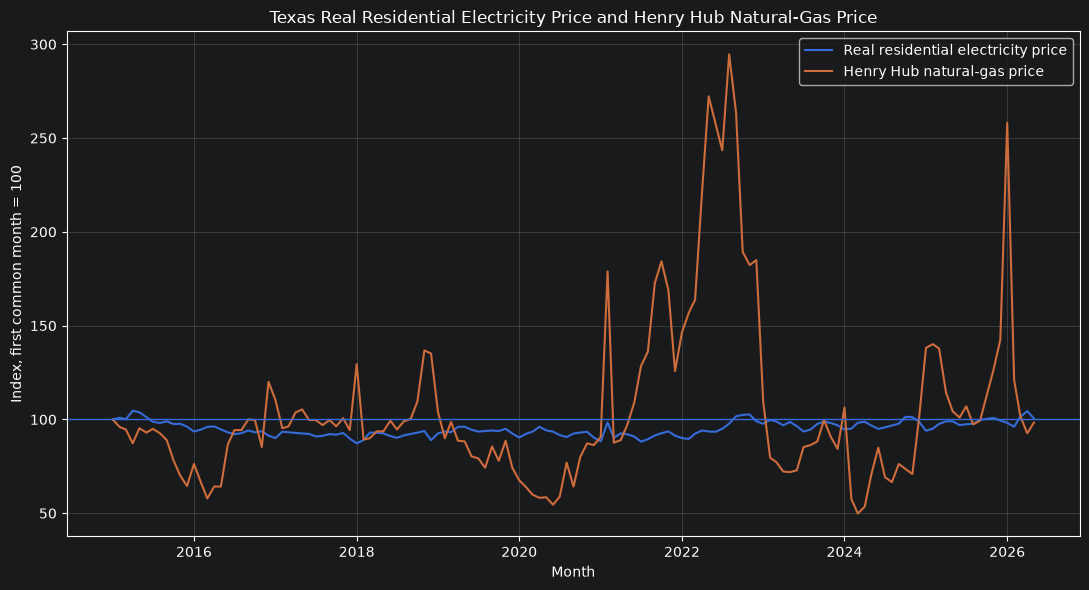

In [4]:
def rebase_to_100(series: pd.Series) -> pd.Series:
    valid = series.dropna()

    if valid.empty:
        raise ValueError(
            "Cannot rebase an entirely missing series."
        )

    base_value = valid.iloc[0]

    if base_value == 0:
        raise ValueError(
            "Cannot rebase a series whose first valid value is zero."
        )

    return series / base_value * 100


price_gas = (
    df[
        [
            "period",
            "residential_price_real_2025_01",
            "henry_hub_natural_gas_price",
        ]
    ]
    .dropna()
    .copy()
)

price_gas["real_residential_price_index"] = rebase_to_100(
    price_gas["residential_price_real_2025_01"]
)

price_gas["henry_hub_price_index"] = rebase_to_100(
    price_gas["henry_hub_natural_gas_price"]
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    price_gas["period"],
    price_gas["real_residential_price_index"],
    label="Real residential electricity price",
)

ax.plot(
    price_gas["period"],
    price_gas["henry_hub_price_index"],
    label="Henry Hub natural-gas price",
)

ax.axhline(100, linewidth=1)
ax.set_title(
    "Texas Real Residential Electricity Price "
    "and Henry Hub Natural-Gas Price"
)
ax.set_xlabel("Month")
ax.set_ylabel("Index, first common month = 100")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_real_residential_price_and_henry_hub_index.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 4. Texas employment growth and WTI crude-oil price changes

Both variables are year-over-year percentage changes.

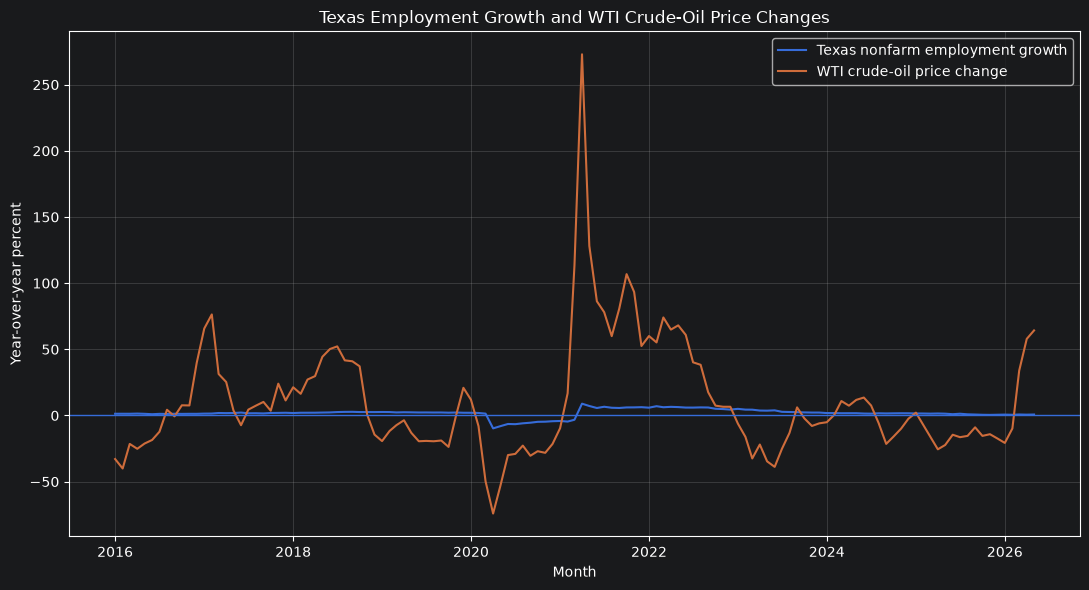

In [5]:
employment_oil = (
    df[
        [
            "period",
            "tx_nonfarm_employment_yoy_pct",
            "wti_crude_oil_price_yoy_pct",
        ]
    ]
    .dropna()
    .copy()
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    employment_oil["period"],
    employment_oil["tx_nonfarm_employment_yoy_pct"],
    label="Texas nonfarm employment growth",
)

ax.plot(
    employment_oil["period"],
    employment_oil["wti_crude_oil_price_yoy_pct"],
    label="WTI crude-oil price change",
)

ax.axhline(0, linewidth=1)
ax.set_title(
    "Texas Employment Growth and WTI Crude-Oil Price Changes"
)
ax.set_xlabel("Month")
ax.set_ylabel("Year-over-year percent")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_employment_growth_and_wti_yoy.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Renewable generation share and real residential electricity prices

Both variables are standardized because they use different units.

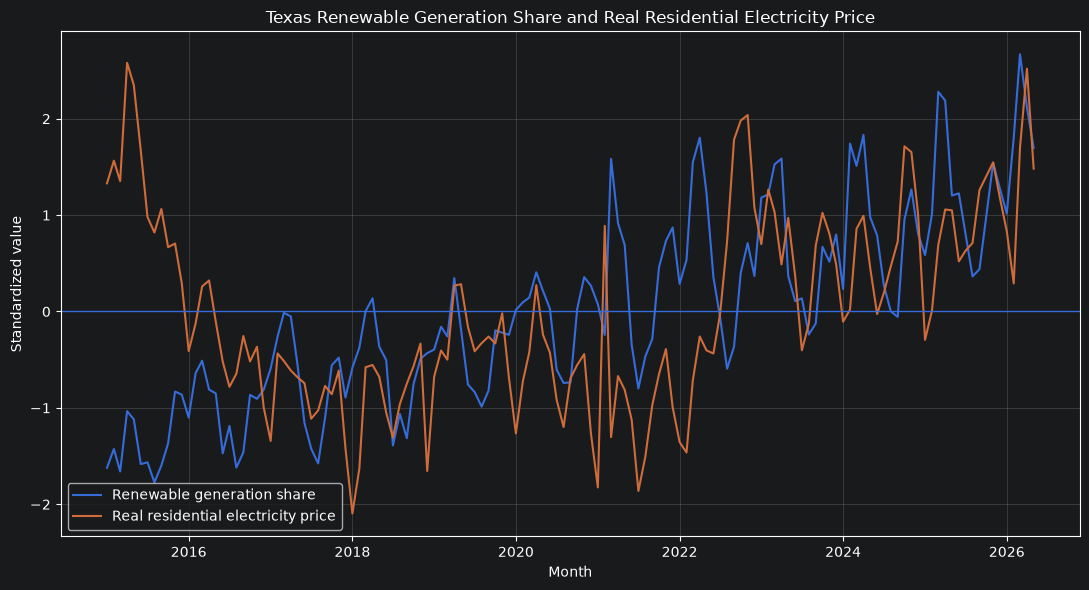

In [6]:
def z_score(series: pd.Series) -> pd.Series:
    standard_deviation = series.std()

    if pd.isna(standard_deviation) or standard_deviation == 0:
        raise ValueError(
            "Cannot standardize a constant or missing series."
        )

    return (
        series - series.mean()
    ) / standard_deviation


renewable_price = (
    df[
        [
            "period",
            "renewable_share",
            "residential_price_real_2025_01",
        ]
    ]
    .dropna()
    .copy()
)

renewable_price["renewable_share_z"] = z_score(
    renewable_price["renewable_share"]
)

renewable_price["real_residential_price_z"] = z_score(
    renewable_price["residential_price_real_2025_01"]
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    renewable_price["period"],
    renewable_price["renewable_share_z"],
    label="Renewable generation share",
)

ax.plot(
    renewable_price["period"],
    renewable_price["real_residential_price_z"],
    label="Real residential electricity price",
)

ax.axhline(0, linewidth=1)
ax.set_title(
    "Texas Renewable Generation Share and "
    "Real Residential Electricity Price"
)
ax.set_xlabel("Month")
ax.set_ylabel("Standardized value")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_renewable_share_and_real_residential_price_zscore.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 6. Correlation matrix

The correlations describe linear co-movement and do not identify causal effects.

In [7]:
CORRELATION_VARIABLES = [
    "residential_price_real_2025_01",
    "henry_hub_natural_gas_price",
    "wti_crude_oil_price_yoy_pct",
    "tx_nonfarm_employment_yoy_pct",
    "tx_unemployment_rate",
    "renewable_share",
    "natural_gas_share",
]

correlation_matrix = df[CORRELATION_VARIABLES].corr()

correlation_matrix.to_csv(
    TABLE_DIRECTORY
    / "energy_economy_correlation_matrix.csv"
)

correlation_matrix.round(3)

,residential_price_real_2025_01,henry_hub_natural_gas_price,wti_crude_oil_price_yoy_pct,tx_nonfarm_employment_yoy_pct,tx_unemployment_rate,renewable_share,natural_gas_share
residential_price_real_2025_01,1.000,0.041,-0.275,0.020,-0.168,0.282,0.094
henry_hub_natural_gas_price,0.041,1.000,0.344,0.457,-0.209,0.155,-0.153
wti_crude_oil_price_yoy_pct,-0.275,0.344,1.000,0.538,-0.104,0.091,-0.296
tx_nonfarm_employment_yoy_pct,0.020,0.457,0.538,1.000,-0.706,0.078,-0.076
tx_unemployment_rate,-0.168,-0.209,-0.104,-0.706,1.000,-0.027,0.014
renewable_share,0.282,0.155,0.091,0.078,-0.027,1.000,-0.503
natural_gas_share,0.094,-0.153,-0.296,-0.076,0.014,-0.503,1.000


## 7. Descriptive lead–lag correlations

For lag `h`, the notebook calculates the correlation between WTI price change in month `t` and Texas employment growth in month `t + h`.

A positive lag means WTI leads employment growth.

In [8]:
def calculate_lead_lag_correlations(
    leading_series: pd.Series,
    response_series: pd.Series,
    maximum_lag: int = 12,
) -> pd.DataFrame:
    rows = []

    for lag in range(
        -maximum_lag,
        maximum_lag + 1,
    ):
        aligned = pd.concat(
            [
                leading_series.rename("leading"),
                response_series.shift(-lag).rename("response"),
            ],
            axis=1,
        ).dropna()

        correlation = (
            aligned["leading"].corr(aligned["response"])
            if len(aligned) >= 3
            else np.nan
        )

        rows.append(
            {
                "lag_months": lag,
                "correlation": correlation,
                "observations": len(aligned),
            }
        )

    return pd.DataFrame(rows)


wti_employment_lags = calculate_lead_lag_correlations(
    leading_series=df[
        "wti_crude_oil_price_yoy_pct"
    ],
    response_series=df[
        "tx_nonfarm_employment_yoy_pct"
    ],
    maximum_lag=12,
)

wti_employment_lags.to_csv(
    TABLE_DIRECTORY
    / "wti_employment_lag_correlations.csv",
    index=False,
)

wti_employment_lags

,lag_months,correlation,observations
0,-12,-0.586542,113
1,-11,-0.567099,114
2,-10,-0.492745,115
3,-9,-0.422924,116
4,-8,-0.347540,117
5,-7,-0.240251,118
6,-6,-0.129562,119
7,-5,-0.050858,120
8,-4,0.011436,121
9,-3,0.091660,122


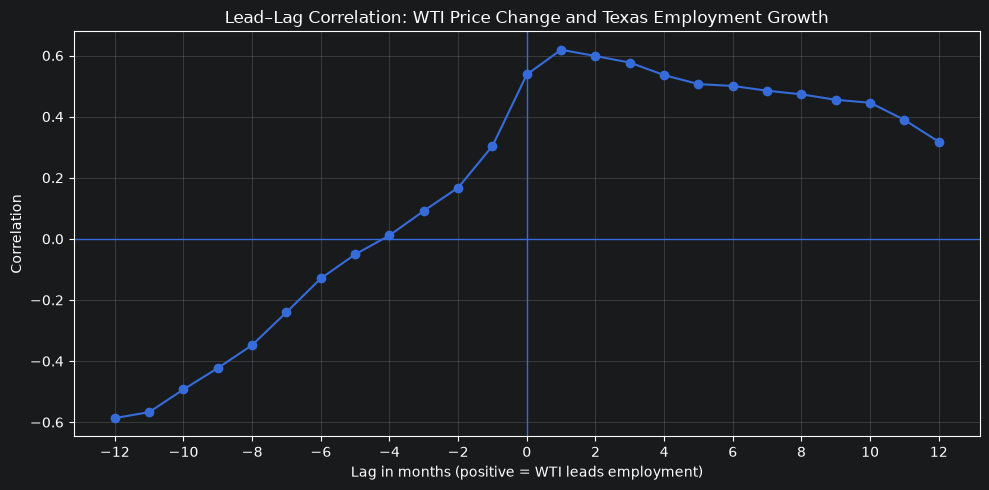

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    wti_employment_lags["lag_months"],
    wti_employment_lags["correlation"],
    marker="o",
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_title(
    "Lead–Lag Correlation: "
    "WTI Price Change and Texas Employment Growth"
)
ax.set_xlabel(
    "Lag in months "
    "(positive = WTI leads employment)"
)
ax.set_ylabel("Correlation")
ax.set_xticks(range(-12, 13, 2))
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURE_DIRECTORY
    / "tx_wti_employment_lag_correlation.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 8. Interpretation notes

Record only patterns that are visibly supported by the figures and tables.

Use phrases such as:

- “moves with”;
- “is correlated with”;
- “shows a similar timing pattern”;
- “the strongest correlation occurs at a lag of … months.”

Avoid causal language such as “causes,” “leads to,” or “has an effect on.”

In [10]:
strongest_correlations = (
    correlation_matrix
    .where(
        ~np.eye(
            len(correlation_matrix),
            dtype=bool,
        )
    )
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(
        columns={
            "level_0": "variable_1",
            "level_1": "variable_2",
        }
    )
)

strongest_correlations["absolute_correlation"] = (
    strongest_correlations["correlation"].abs()
)

strongest_correlations = (
    strongest_correlations
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .drop_duplicates(
        subset=["absolute_correlation"]
    )
    .head(10)
    .reset_index(drop=True)
)

strongest_correlations

,variable_1,variable_2,correlation,absolute_correlation
0,tx_unemployment_rate,tx_nonfarm_employment_yoy_pct,-0.705883,0.705883
1,wti_crude_oil_price_yoy_pct,tx_nonfarm_employment_yoy_pct,0.537950,0.537950
2,natural_gas_share,renewable_share,-0.502852,0.502852
3,henry_hub_natural_gas_price,tx_nonfarm_employment_yoy_pct,0.456657,0.456657
4,wti_crude_oil_price_yoy_pct,henry_hub_natural_gas_price,0.344093,0.344093
5,natural_gas_share,wti_crude_oil_price_yoy_pct,-0.296448,0.296448
6,renewable_share,residential_price_real_2025_01,0.282094,0.282094
7,residential_price_real_2025_01,wti_crude_oil_price_yoy_pct,-0.274548,0.274548
8,tx_unemployment_rate,henry_hub_natural_gas_price,-0.209004,0.209004
9,residential_price_real_2025_01,tx_unemployment_rate,-0.168408,0.168408
